# Predição (LightGBM) com feature_engineering_simple — dados RAW

In [ ]:
MODEL_PATH = r"../models/model_lgbm_nb.joblib"
import sys
from pathlib import Path
sys.path.append(str(Path("../").resolve())); sys.path.append(str(Path("../src").resolve()))

In [2]:
import re, numpy as np, pandas as pd, joblib, matplotlib.pyplot as plt
import src.data.feature_engineering_simple as fe
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
pd.set_option('display.max_columns', None)

### Conjunto de features engineered (mesmas do treino, sem as vazias removidas)

In [4]:
ENGINEERED = [
    "cand_cidade","cand_uf","cand_regiao","vaga_uf","vaga_cidade_unif","vaga_regiao",
    "same_state","same_city","same_region",
    "meets_academic","meets_english","meets_spanish",
    "sim_tfidf","overlap_kw","jaccard_kw",
    "cand_remuneracao_num",
    "vaga_is_CLT","vaga_is_PJ","vaga_is_Estagiario","vaga_is_Cotas",
    "cand_is_Junior","cand_is_Pleno","cand_is_Senior",
    "vaga_is_Junior","vaga_is_Pleno","vaga_is_Senior",
]

### Funções auxiliares para montar texto, flags e engineered a partir de RAW

In [5]:
def build_text_from_raw_cand(cand: dict) -> str:
    parts = [
        cand.get("conhecimentos_tecnicos",""),
        cand.get("certificacoes",""),
        cand.get("outras_certificacoes",""),
        cand.get("titulo_profissional",""),
        cand.get("area_atuacao",""),
        cand.get("cv_text",""),
    ]
    return " ".join([p for p in parts if isinstance(p, str)])

def build_text_from_raw_vaga(vaga: dict) -> str:
    parts = [
        vaga.get("titulo_vaga",""),
        vaga.get("principais_atividades",""),
        vaga.get("competencias",""),
        vaga.get("areas_atuacao",""),
        vaga.get("demais_observacoes",""),
        vaga.get("descricao",""),
    ]
    return " ".join([p for p in parts if isinstance(p, str)])

def hiring_flags(tipo: str):
    t = (tipo or "").lower()
    return int("clt" in t), int("pj" in t), int("estag" in t), int("cota" in t)

def seniority_flags(s: str):
    s = (s or "").lower()
    return int(("junior" in s) or ("júnior" in s)), int("pleno" in s), int(("senior" in s) or ("sênior" in s))

In [6]:
def build_engineered_from_raw(cand: dict, vaga: dict) -> pd.DataFrame:
    # --- Geografia
    cand_uf = cand.get("uf"); vaga_uf = vaga.get("uf")
    cand_city = cand.get("cidade"); vaga_city = vaga.get("cidade")
    out = {
        "cand_cidade": cand_city,
        "cand_uf": cand_uf,
        "cand_regiao": fe.uf_to_region(cand_uf),
        "vaga_uf": vaga_uf,
        "vaga_cidade_unif": vaga_city,
        "vaga_regiao": fe.uf_to_region(vaga_uf),
    }
    out["same_state"]  = int((out["cand_uf"] and out["vaga_uf"]) and (str(out["cand_uf"]).upper()==str(out["vaga_uf"]).upper()))
    out["same_city"]   = int(out["same_state"] and (str(out["cand_cidade"]).lower()==str(out["vaga_cidade_unif"]).lower()))
    out["same_region"] = int((out["cand_regiao"] is not None) and (out["vaga_regiao"] is not None) and (out["cand_regiao"]==out["vaga_regiao"]))

    # --- Meets a partir dos níveis informados (RAW)
    cand_acad = fe.academic_rank(cand.get("nivel_academico"))
    vaga_acad = fe.academic_rank(vaga.get("nivel_academico"))
    out["meets_academic"] = int(pd.notna(cand_acad) and pd.notna(vaga_acad) and (cand_acad >= vaga_acad))

    cand_eng = fe.lang_rank(cand.get("nivel_ingles"))
    vaga_eng = fe.lang_rank(vaga.get("nivel_ingles"))
    out["meets_english"] = int(pd.notna(cand_eng) and pd.notna(vaga_eng) and (cand_eng >= vaga_eng))

    cand_esp = fe.lang_rank(cand.get("nivel_espanhol"))
    vaga_esp = fe.lang_rank(vaga.get("nivel_espanhol"))
    out["meets_spanish"] = int(pd.notna(cand_esp) and pd.notna(vaga_esp) and (cand_esp >= vaga_esp))

    # --- Texto e métricas
    cand_text = build_text_from_raw_cand(cand)
    vaga_text = build_text_from_raw_vaga(vaga)
    out["sim_tfidf"] = fe.tfidf_sim(cand_text, vaga_text)
    ov, jacc = fe.overlap_and_jaccard(cand_text, vaga_text)
    out["overlap_kw"] = ov
    out["jaccard_kw"] = jacc

    # --- Remuneração do candidato
    out["cand_remuneracao_num"] = cand.get("remuneracao_num")
    if out["cand_remuneracao_num"] is None:
        out["cand_remuneracao_num"] = fe.to_float_money(str(cand.get("remuneracao","")))

    # --- Tipo de contratação e senioridade
    clt, pj, est, cot = hiring_flags(vaga.get("tipo_contratacao",""))
    out["vaga_is_CLT"] = clt; out["vaga_is_PJ"] = pj
    out["vaga_is_Estagiario"] = est; out["vaga_is_Cotas"] = cot

    cjun, cple, csen = seniority_flags(cand.get("nivel_profissional",""))
    vjun, vple, vsen = seniority_flags(vaga.get("nivel_profissional",""))
    out["cand_is_Junior"] = cjun; out["cand_is_Pleno"] = cple; out["cand_is_Senior"] = csen
    out["vaga_is_Junior"] = vjun; out["vaga_is_Pleno"]  = vple; out["vaga_is_Senior"] = vsen

    return pd.DataFrame([{k: out.get(k) for k in ENGINEERED}])

## 1) Exemplo RAW (edite livremente)

In [7]:
cand_raw = {
    "cidade": "São Paulo",
    "uf": "SP",
    "nivel_academico": "Ensino Superior Completo",
    "nivel_ingles": "Avançado",
    "nivel_espanhol": "Intermediário",
    "nivel_profissional": "Pleno",
    "conhecimentos_tecnicos": "Python, SQL, Airflow, ETL, modelagem de dados, ciência de dados",
    "certificacoes": "AWS Cloud Practitioner",
    "outras_certificacoes": "",
    "titulo_profissional": "Engenheiro de Dados",
    "area_atuacao": "Dados",
    "cv_text": "",
    "remuneracao_num": 16000,
}
vaga_raw = {
    "cidade": "São Paulo",
    "uf": "SP",
    "nivel_academico": "Ensino Superior Completo",
    "nivel_ingles": "Intermediário",
    "nivel_espanhol": "Básico",
    "nivel_profissional": "Pleno",
    "tipo_contratacao": "CLT",
    "titulo_vaga": "Engenheiro de Dados",
    "principais_atividades": "Construção de pipelines ETL, orquestração (Airflow) e otimização de consultas SQL",
    "competencias": "Python, SQL, Airflow",
    "areas_atuacao": "Dados",
    "demais_observacoes": "Desejável experiência com cloud",
    "descricao": "",
}

X_new = build_engineered_from_raw(cand_raw, vaga_raw)
display(X_new)

,cand_cidade,cand_uf,cand_regiao,vaga_uf,vaga_cidade_unif,vaga_regiao,same_state,same_city,same_region,meets_academic,meets_english,meets_spanish,sim_tfidf,overlap_kw,jaccard_kw,cand_remuneracao_num,vaga_is_CLT,vaga_is_PJ,vaga_is_Estagiario,vaga_is_Cotas,cand_is_Junior,cand_is_Pleno,cand_is_Senior,vaga_is_Junior,vaga_is_Pleno,vaga_is_Senior
0,São Paulo,SP,Sudeste,SP,São Paulo,Sudeste,1,1,1,1,1,1,0.612841,7,0.368421,16000,1,0,0,0,0,1,0,0,1,0


In [8]:
X_new[['sim_tfidf','overlap_kw', 'jaccard_kw', 'cand_remuneracao_num', 'vaga_is_CLT']]

,sim_tfidf,overlap_kw,jaccard_kw,cand_remuneracao_num,vaga_is_CLT
0,0.612841,7,0.368421,16000,1


## 2) Carregar modelo e prever

In [9]:
pipe = joblib.load(MODEL_PATH)
proba = pipe.predict_proba(X_new)[:, 1][0]
print(f"Probabilidade prevista de contratação: {proba:.4f}")

Probabilidade prevista de contratação: 0.5621


## 3) Importância Global e Local

,feature_original,importance
13,sim_tfidf,1875.0
5,jaccard_kw,1543.0
9,overlap_kw,1159.0
14,vaga,1156.0
0,cand,1077.0
4,cand_remuneracao_num,671.0
21,vaga_is_Senior,291.0
15,vaga_is_CLT,274.0
19,vaga_is_PJ,199.0
20,vaga_is_Pleno,169.0


,feature_original,contribution,abs_contribution
0,vaga_is_PJ,0.537382,0.537382
1,jaccard_kw,0.482452,0.482452
2,cand_remuneracao_num,-0.337335,0.337335
3,overlap_kw,-0.215780,0.215780
4,vaga_is_CLT,0.126365,0.126365
5,vaga_is_Pleno,-0.122051,0.122051
6,meets_english,0.117955,0.117955
7,sim_tfidf,0.089497,0.089497
8,vaga_is_Senior,-0.077908,0.077908
9,vaga,-0.062560,0.062560


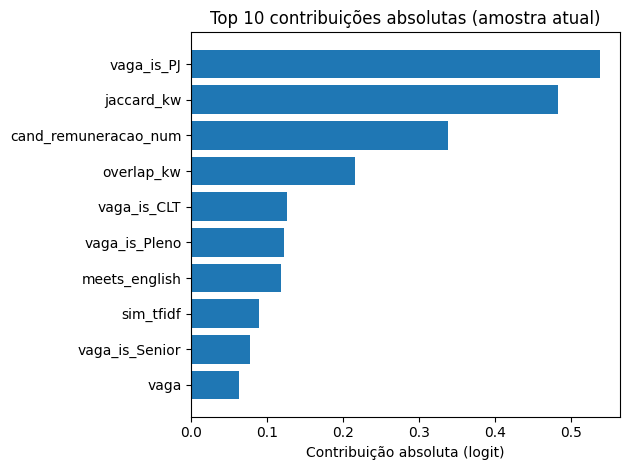

In [10]:
pre = pipe.named_steps["pre"]; clf = pipe.named_steps["clf"]
feat_names = pre.get_feature_names_out()
imps = np.asarray(getattr(clf, "feature_importances_", np.zeros(len(feat_names))), dtype=float)
imp_df = pd.DataFrame({"feature_encoded": feat_names, "importance": imps})

def original_col(name: str) -> str:
    if name.startswith("cat__"):
        rest = name.split("cat__", 1)[1]
        return rest.split("_", 1)[0]
    if name.startswith("num__"):
        return name.split("num__", 1)[1]
    return name

imp_df["feature_original"] = imp_df["feature_encoded"].apply(original_col)
imp_global = imp_df.groupby("feature_original", as_index=False)["importance"].sum().sort_values("importance", ascending=False)
display(imp_global.head(30))

# Local
X_enc = pre.transform(X_new)
X_dense = X_enc.toarray() if hasattr(X_enc, "toarray") else np.asarray(X_enc, dtype=float)
contrib = clf.predict(X_dense, pred_contrib=True)
contrib0 = np.asarray(contrib, dtype=float)[0, :-1].astype(float).ravel()

local_df = pd.DataFrame({"feature_encoded": feat_names, "contribution": contrib0})
local_df["feature_original"] = local_df["feature_encoded"].apply(original_col)
local_agg = local_df.groupby("feature_original", as_index=False)["contribution"].sum()
local_agg["abs_contribution"] = local_agg["contribution"].abs()
local_agg = local_agg.sort_values(by="abs_contribution", ascending=False, kind="mergesort").reset_index(drop=True)
display(local_agg.head(20))

# gráfico top 10
topN = 10
plot_df = local_agg.head(topN).iloc[::-1]
plt.figure()
plt.barh(plot_df["feature_original"], plot_df["abs_contribution"])
plt.title("Top 10 contribuições absolutas (amostra atual)")
plt.xlabel("Contribuição absoluta (logit)")
plt.tight_layout()
plt.show()


## 5) Predições em lote via **CSV** (gera exemplo e processa)

Nesta seção:
1. **Geramos** um CSV de exemplo com **vários registros sintéticos** (campos RAW do candidato e da vaga com **prefixos** `cand_` e `vaga_` para evitar colisões).
2. **Carregamos** um CSV (padrão: o exemplo gerado) e **prevemos em lote** as probabilidades de contratação.
3. Salvamos um CSV de saída com as probabilidades.


In [11]:
# 5.1) Gerar CSV de exemplo (campos RAW de cand_ e vaga_)
from pathlib import Path

BATCH_INPUT_CSV = Path("synthetic_batch_input.csv")
BATCH_OUTPUT_CSV = Path("synthetic_batch_predictions.csv")

rows = [
    {
        "cand_cidade": "São Paulo", "cand_uf": "SP",
        "cand_nivel_academico": "Ensino Superior Completo",
        "cand_nivel_ingles": "Avançado",
        "cand_nivel_espanhol": "Intermediário",
        "cand_nivel_profissional": "Pleno",
        "cand_conhecimentos_tecnicos": "Python, SQL, Airflow, ETL, modelagem de dados",
        "cand_certificacoes": "AWS Cloud Practitioner",
        "cand_outras_certificacoes": "",
        "cand_titulo_profissional": "Engenheiro de Dados",
        "cand_area_atuacao": "Dados",
        "cand_cv_text": "",
        "cand_remuneracao_num": 16000,

        "vaga_cidade": "São Paulo", "vaga_uf": "SP",
        "vaga_nivel_academico": "Ensino Superior Completo",
        "vaga_nivel_ingles": "Intermediário",
        "vaga_nivel_espanhol": "Básico",
        "vaga_nivel_profissional": "Pleno",
        "vaga_tipo_contratacao": "CLT",
        "vaga_titulo_vaga": "Engenheiro de Dados",
        "vaga_principais_atividades": "Construção de pipelines ETL, orquestração (Airflow)",
        "vaga_competencias": "Python, SQL, Airflow",
        "vaga_areas_atuacao": "Dados",
        "vaga_demais_observacoes": "Desejável experiência com cloud",
        "vaga_descricao": "",
    },
    {
        "cand_cidade": "Rio de Janeiro", "cand_uf": "RJ",
        "cand_nivel_academico": "Ensino Superior Completo",
        "cand_nivel_ingles": "Intermediário",
        "cand_nivel_espanhol": "Nenhum",
        "cand_nivel_profissional": "Júnior",
        "cand_conhecimentos_tecnicos": "Java, Spring, REST APIs",
        "cand_certificacoes": "",
        "cand_outras_certificacoes": "",
        "cand_titulo_profissional": "Desenvolvedor Backend",
        "cand_area_atuacao": "Desenvolvimento",
        "cand_cv_text": "",
        "cand_remuneracao_num": 8000,

        "vaga_cidade": "Rio de Janeiro", "vaga_uf": "RJ",
        "vaga_nivel_academico": "Ensino Superior Incompleto",
        "vaga_nivel_ingles": "Básico",
        "vaga_nivel_espanhol": "Nenhum",
        "vaga_nivel_profissional": "Júnior",
        "vaga_tipo_contratacao": "PJ",
        "vaga_titulo_vaga": "Dev Backend Java",
        "vaga_principais_atividades": "Desenvolvimento de APIs com Spring Boot",
        "vaga_competencias": "Java, Spring, SQL",
        "vaga_areas_atuacao": "Desenvolvimento",
        "vaga_demais_observacoes": "",
        "vaga_descricao": "",
    },
    {
        "cand_cidade": "Curitiba", "cand_uf": "PR",
        "cand_nivel_academico": "Pós-Graduação",
        "cand_nivel_ingles": "Fluente",
        "cand_nivel_espanhol": "Avançado",
        "cand_nivel_profissional": "Sênior",
        "cand_conhecimentos_tecnicos": "Python, Machine Learning, Scikit-learn, XGBoost",
        "cand_certificacoes": "AWS Solutions Architect",
        "cand_outras_certificacoes": "",
        "cand_titulo_profissional": "Cientista de Dados",
        "cand_area_atuacao": "Dados",
        "cand_cv_text": "",
        "cand_remuneracao_num": 22000,

        "vaga_cidade": "São Paulo", "vaga_uf": "SP",
        "vaga_nivel_academico": "Ensino Superior Completo",
        "vaga_nivel_ingles": "Avançado",
        "vaga_nivel_espanhol": "Intermediário",
        "vaga_nivel_profissional": "Sênior",
        "vaga_tipo_contratacao": "CLT",
        "vaga_titulo_vaga": "Senior Data Scientist",
        "vaga_principais_atividades": "Modelagem preditiva, avaliação de modelos, MLOps",
        "vaga_competencias": "Python, ML, Cloud",
        "vaga_areas_atuacao": "Dados",
        "vaga_demais_observacoes": "Experiência prévia com times de produto",
        "vaga_descricao": "",
    },
]

df_in = pd.DataFrame(rows)
df_in.to_csv(BATCH_INPUT_CSV, index=False, encoding="utf-8")
print(f"Arquivo CSV de entrada gerado em: {BATCH_INPUT_CSV}")
df_in.head()

Arquivo CSV de entrada gerado em: synthetic_batch_input.csv


,cand_cidade,cand_uf,cand_nivel_academico,cand_nivel_ingles,cand_nivel_espanhol,cand_nivel_profissional,cand_conhecimentos_tecnicos,cand_certificacoes,cand_outras_certificacoes,cand_titulo_profissional,cand_area_atuacao,cand_cv_text,cand_remuneracao_num,vaga_cidade,vaga_uf,vaga_nivel_academico,vaga_nivel_ingles,vaga_nivel_espanhol,vaga_nivel_profissional,vaga_tipo_contratacao,vaga_titulo_vaga,vaga_principais_atividades,vaga_competencias,vaga_areas_atuacao,vaga_demais_observacoes,vaga_descricao
0,São Paulo,SP,Ensino Superior Completo,Avançado,Intermediário,Pleno,"Python, SQL, Airflow, ETL, modelagem de dados",AWS Cloud Practitioner,,Engenheiro de Dados,Dados,,16000,São Paulo,SP,Ensino Superior Completo,Intermediário,Básico,Pleno,CLT,Engenheiro de Dados,"Construção de pipelines ETL, orquestração (Air...","Python, SQL, Airflow",Dados,Desejável experiência com cloud,
1,Rio de Janeiro,RJ,Ensino Superior Completo,Intermediário,Nenhum,Júnior,"Java, Spring, REST APIs",,,Desenvolvedor Backend,Desenvolvimento,,8000,Rio de Janeiro,RJ,Ensino Superior Incompleto,Básico,Nenhum,Júnior,PJ,Dev Backend Java,Desenvolvimento de APIs com Spring Boot,"Java, Spring, SQL",Desenvolvimento,,
2,Curitiba,PR,Pós-Graduação,Fluente,Avançado,Sênior,"Python, Machine Learning, Scikit-learn, XGBoost",AWS Solutions Architect,,Cientista de Dados,Dados,,22000,São Paulo,SP,Ensino Superior Completo,Avançado,Intermediário,Sênior,CLT,Senior Data Scientist,"Modelagem preditiva, avaliação de modelos, MLOps","Python, ML, Cloud",Dados,Experiência prévia com times de produto,


In [12]:
# 5.2) Ler CSV e prever em lote
from pathlib import Path

def row_to_raw_dicts(row):
    cand = {k.replace("cand_", ""): row[k] for k in row.index if k.startswith("cand_")}
    vaga = {k.replace("vaga_", ""): row[k] for k in row.index if k.startswith("vaga_")}
    for d in (cand, vaga):
        for k, v in list(d.items()):
            if isinstance(v, float) and np.isnan(v):
                d[k] = None
    return cand, vaga

def batch_predict(input_csv: Path, output_csv: Path):
    df_in = pd.read_csv(input_csv)
    engineered_list = []
    for _, row in df_in.iterrows():
        cand_raw, vaga_raw = row_to_raw_dicts(row)
        Xi = build_engineered_from_raw(cand_raw, vaga_raw)
        engineered_list.append(Xi)
    X_batch = pd.concat(engineered_list, axis=0).reset_index(drop=True)
    proba = pipe.predict_proba(X_batch)[:, 1]
    df_out = df_in.copy()
    df_out["prob_contratado"] = proba
    df_out.to_csv(output_csv, index=False, encoding="utf-8")
    return df_out, X_batch

df_preds, X_batch = batch_predict(BATCH_INPUT_CSV, BATCH_OUTPUT_CSV)
print(f"Predições salvas em: {BATCH_OUTPUT_CSV}")
df_preds.head()

Predições salvas em: synthetic_batch_predictions.csv


,cand_cidade,cand_uf,cand_nivel_academico,cand_nivel_ingles,cand_nivel_espanhol,cand_nivel_profissional,cand_conhecimentos_tecnicos,cand_certificacoes,cand_outras_certificacoes,cand_titulo_profissional,cand_area_atuacao,cand_cv_text,cand_remuneracao_num,vaga_cidade,vaga_uf,vaga_nivel_academico,vaga_nivel_ingles,vaga_nivel_espanhol,vaga_nivel_profissional,vaga_tipo_contratacao,vaga_titulo_vaga,vaga_principais_atividades,vaga_competencias,vaga_areas_atuacao,vaga_demais_observacoes,vaga_descricao,prob_contratado
0,São Paulo,SP,Ensino Superior Completo,Avançado,Intermediário,Pleno,"Python, SQL, Airflow, ETL, modelagem de dados",AWS Cloud Practitioner,NaN,Engenheiro de Dados,Dados,NaN,16000,São Paulo,SP,Ensino Superior Completo,Intermediário,Básico,Pleno,CLT,Engenheiro de Dados,"Construção de pipelines ETL, orquestração (Air...","Python, SQL, Airflow",Dados,Desejável experiência com cloud,NaN,0.553396
1,Rio de Janeiro,RJ,Ensino Superior Completo,Intermediário,Nenhum,Júnior,"Java, Spring, REST APIs",NaN,NaN,Desenvolvedor Backend,Desenvolvimento,NaN,8000,Rio de Janeiro,RJ,Ensino Superior Incompleto,Básico,Nenhum,Júnior,PJ,Dev Backend Java,Desenvolvimento de APIs com Spring Boot,"Java, Spring, SQL",Desenvolvimento,NaN,NaN,0.250917
2,Curitiba,PR,Pós-Graduação,Fluente,Avançado,Sênior,"Python, Machine Learning, Scikit-learn, XGBoost",AWS Solutions Architect,NaN,Cientista de Dados,Dados,NaN,22000,São Paulo,SP,Ensino Superior Completo,Avançado,Intermediário,Sênior,CLT,Senior Data Scientist,"Modelagem preditiva, avaliação de modelos, MLOps","Python, ML, Cloud",Dados,Experiência prévia com times de produto,NaN,0.387770
